<a href="https://colab.research.google.com/github/sivashobana547/Wholesale-Customers-Clustering-Analysis/blob/main/unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
ds=pd.read_csv('/content/Wholesale customers data - Wholesale customers data.csv')
ds

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [ ]:
ds.isna().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
ds.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ds.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Channel')
numerical_cols.remove('Region')
ds_numerical = ds[numerical_cols]
scaler = StandardScaler()
ds_scaled = scaler.fit_transform(ds_numerical)

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(ds_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
cluster_labels = kmeans.labels_
ds['cluster_label'] = cluster_labels
display(ds.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster_label
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,3
2,2,3,6353,8808,7684,2405,3516,7844,3
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


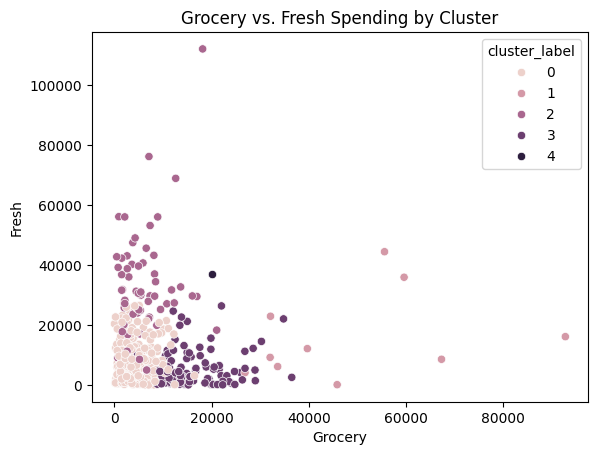

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='Grocery', y='Fresh', hue='cluster_label', data=ds,)
plt.title("Grocery vs. Fresh Spending by Cluster")
plt.show()


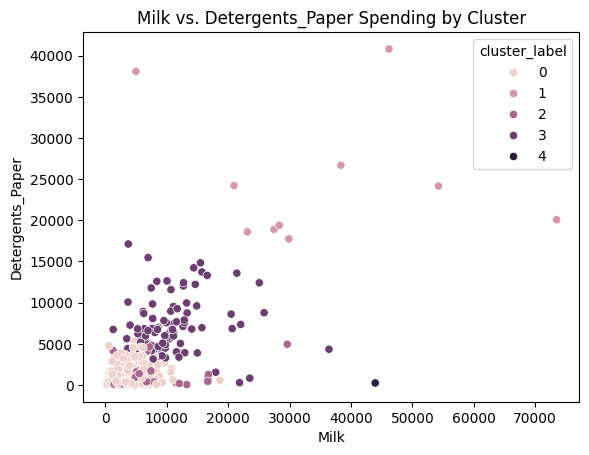

In [ ]:
sns.scatterplot(x='Milk', y='Detergents_Paper', hue='cluster_label', data=ds)
plt.title("Milk vs. Detergents_Paper Spending by Cluster")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(ds_scaled)
ds['cluster'] = dbscan.labels_
print(ds['cluster'])

0      0
1      0
2     -1
3      0
4     -1
      ..
435   -1
436   -1
437   -1
438    0
439    0
Name: cluster, Length: 440, dtype: int64


In [ ]:
ds['cluster'] = dbscan.labels_
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(ds_scaled, ds['cluster'])
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.1958113956262888


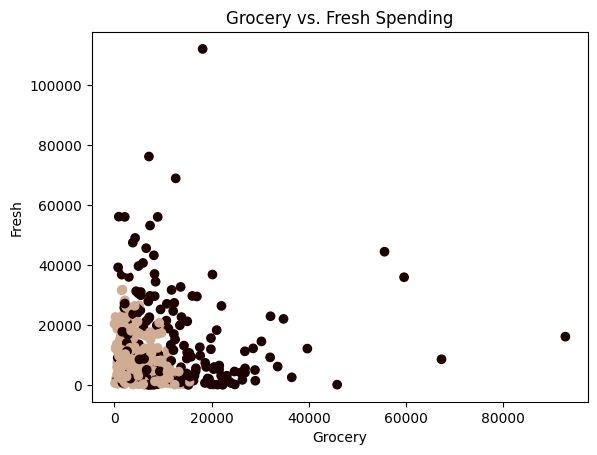

In [ ]:
plt.scatter(ds['Grocery'], ds['Fresh'], c=ds['cluster'], cmap='pink')
plt.xlabel('Grocery')
plt.ylabel('Fresh')
plt.title('Grocery vs. Fresh Spending')
plt.show()